## Skin Cancer Detection

In [1]:
import os
import time, json
# from ddgs import DDGS 
from fastcore.all import *
from fastdownload import download_url
from fastai.vision.all import *
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


Steps for this project:

1. Use DuckDuckGo to search for images of "bird photos"
1. Use DuckDuckGo to search for images of "forest photos"
1. Fine-tune a pretrained neural network to recognise these two groups
1. Try running this model on a picture of a bird and see if it works.

## Step 1: Download images of malignant and benign lesions

In [2]:
path = Path.home()/'AI-From-Scratch-Playground/02_Deep_Learning/00_Practical_Deep_Learning_for_Coders/data'

df = pd.read_csv(path/'HAM10000_metadata.csv')
df['dx'].value_counts() # diagnosis

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

#### Malignant Lesions

- **Actinic Keratoses** (`akiec`)<br>
  Precancerous skin lesions that may develop into squamous cell carcinoma.

- **Basal Cell Carcinoma** (`bcc`)<br>
  A common and slow-growing type of skin cancer that rarely spreads.

- **Melanoma** (`mel`)<br>
  An aggressive and potentially fatal form of skin cancer that develops in melanocytes.

#### Benign Lesions

- **Benign Keratosis-like Lesions** (`bkl`)<br>
  Non-cancerous growths, including seborrheic keratoses and solar lentigines.

- **Dermatofibroma** (`df`)<br>
  Small, firm nodules that are benign skin tumors.

- **Melanocytic Nevi** (`nv`)<br>
  Commonly known as moles or beauty marks, these are benign accumulations of melanocytes.

- **Vascular Lesions** (`vasc`)<br>
  Benign abnormalities of blood vessels, such as hemangiomas or angiomas.

In [3]:
malignant = ['akiec', 'bcc', 'mel']
benign = ['bkl', 'df', 'nv', 'vasc']

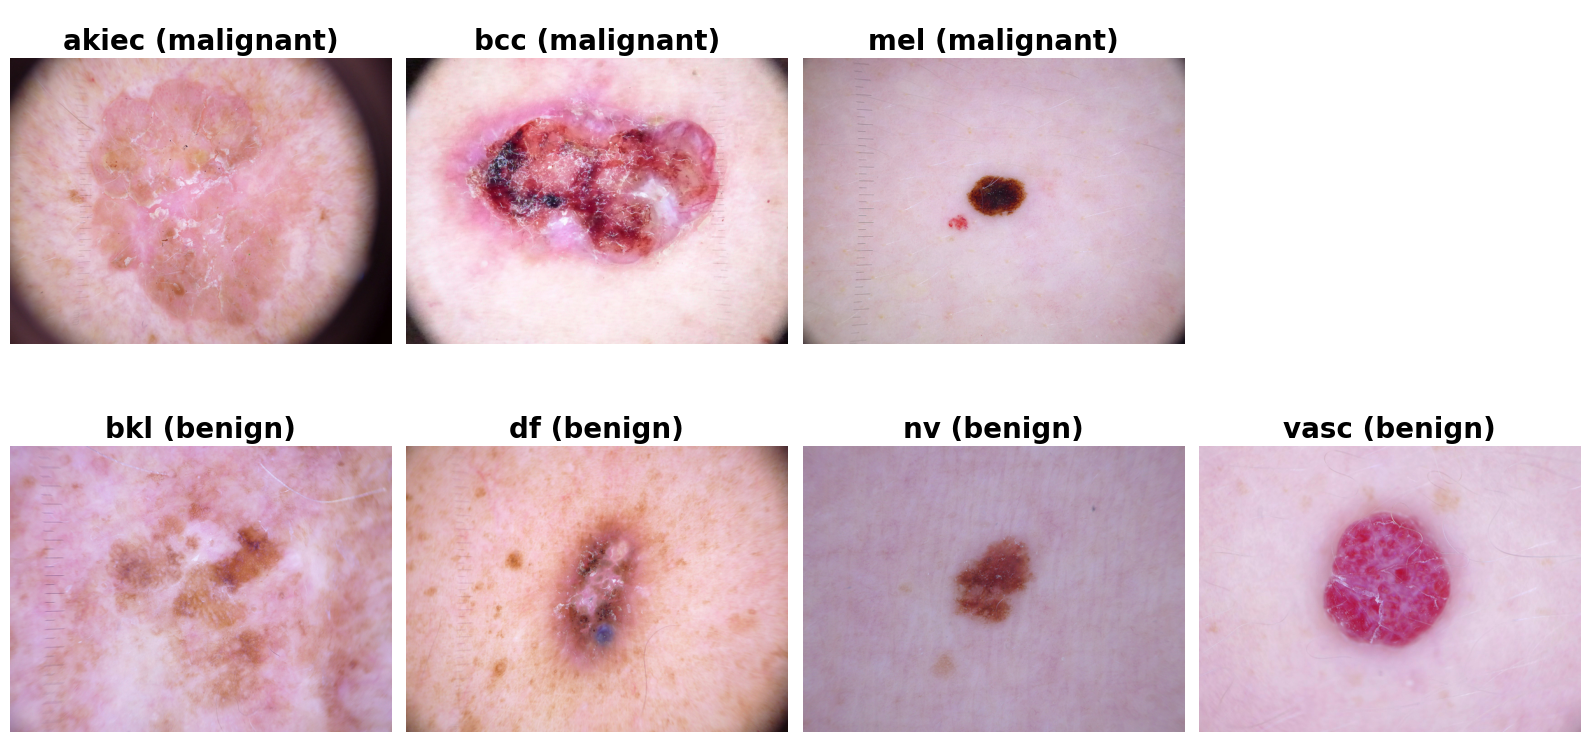

In [4]:
def get_image(row):
    image_path = path/'HAM10000_images_part_1'/f"{row['image_id']}.jpg"
    if image_path.exists():
        return image_path 
    else:
        return path/'HAM10000_images_part_2'/f"{row['image_id']}.jpg"

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# row 1: malignant
for i, dx in enumerate(malignant):
    row = df[df['dx'] == dx].iloc[0]
    img = PILImage.create(get_image(row))
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"{dx} (malignant)", fontsize=20, fontweight='bold')
    axes[0, i].axis('off')
axes[0, 3].axis('off')

# row 2: benign
for i, dx in enumerate(benign):
    row = df[df['dx'] == dx].iloc[0]
    img = PILImage.create(get_image(row))
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"{dx} (benign)", fontsize=20, fontweight='bold')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## Step 2: Train our model

To train a model, we'll need `DataLoaders`, which is an object that contains a *training set* (the images used to create a model) and a *validation set* (the images used to check the accuracy of a model -- not used during training). In `fastai` we can create that easily using a `DataBlock`, and view sample images from it:

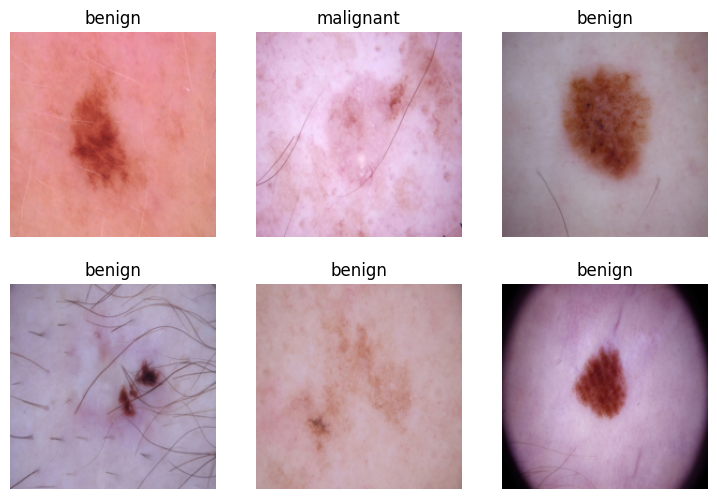

In [5]:
def get_label(row):
    return 'malignant' if row['dx'] in malignant else 'benign'

dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_x=get_image, 
    get_y=get_label,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=[Resize(192, method='squish')]
).dataloaders(df, bs=32)

dls.show_batch(max_n=6)

Here what each of the `DataBlock` parameters means:

    blocks=(ImageBlock, CategoryBlock),

The inputs to our model are images, and the outputs are categories (in this case, "bird" or "forest").

    get_x=get_image, 

To find all the inputs to our model, run the `get_image` function (which returns a list of all image files in a path).

    splitter=RandomSplitter(valid_pct=0.2, seed=42),

Split the data into training and validation sets randomly, using 20% of the data for the validation set.

    get_y=get_label,

The labels (`y` values) is the category of each lesion (*malignant* or *benign*).

    item_tfms=[Resize(192, method='squish')]

Before training, resize each image to 192x192 pixels by "squishing" it (as opposed to cropping it).

Now we're ready to train our model. The fastest widely used computer vision model is `resnet18`. 

`fastai` comes with a helpful `fine_tune()` method which automatically uses best practices for fine tuning a pre-trained model, so we'll use that.

In [6]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(2)

epoch,train_loss,valid_loss,error_rate,time
0,0.562326,0.459770,0.208188,00:09


epoch,train_loss,valid_loss,error_rate,time
0,0.364578,0.330369,0.157264,00:08
1,0.204281,0.296278,0.125811,00:08


Generally when I run this `valid_loss` start to increase from epoch 2. (although it might vary a bit from run to run).

"Fine-tuning" a model means that we're starting with a model someone else has trained using some other dataset (called the *pretrained model*), and adjusting the weights a little bit so that the model learns to recognise your particular dataset. In this case, the pretrained model was trained to recognise photos in *imagenet*, and widely-used computer vision dataset with images covering 1000 categories) For details on fine-tuning and why it's important, check out the [free fast.ai course](https://course.fast.ai/).

## Step 3: Test images

Let's see what our model thinks about random benign lesion image from google:

In [7]:
is_malignant, _, probs = learn.predict(PILImage.create(path/'Benign_Test.jpg'))
print(f"This is a \"{is_malignant}\" lesion.")
print(f"Probability it's a benign lesion: {probs[0]:.4f}")

This is a "benign" lesion.
Probability it's a benign lesion: 0.9944


In [8]:
is_malignant, _, probs = learn.predict(PILImage.create(path/'Benign_Test2.jpg'))
print(f"This is a \"{is_malignant}\" lesion.")
print(f"Probability it's a benign lesion: {probs[0]:.4f}")

This is a "benign" lesion.
Probability it's a benign lesion: 0.9960
